# ARIMAX

In [7]:
#path config set
import sys
from pathlib import Path

project_root = Path.cwd().parent
for folder in ["functions", "other"]:
    p = str(project_root / folder)
    if p not in sys.path:
        sys.path.append(p)

In [34]:
# import potrebnych kniznic a konfiguracia notebooku
%load_ext autoreload
%autoreload 2

#import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from pmdarima import auto_arima

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from cred import DATA_PATH_CRED
from functions_arimax import forward_selection, rolling_forecast_arimax
from functions_general import forecast_plot

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.figsize": (13, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print("Importy uspesne.")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Importy uspesne.


In [9]:
# konfiguracia a stiahnutie dat
main_dir = Path(DATA_PATH_CRED)
data_mod = "data_mod.csv"
pp_orig = "data.xlsx"
DATA_PATH_DATA_MOD  = main_dir / data_mod
DATA_PATH_DATA = main_dir / pp_orig
SHEET_NAME_PP = "pp"
SHEET_NAME_EXOG = "exog"
TARGET_VAR = "pp_sa_ca_jd"
TEST_SIZE = 24

df_raw = pd.read_csv(DATA_PATH_DATA_MOD)
df_raw["datum"] = pd.to_datetime(df_raw["datum"])
df_raw = df_raw.set_index("datum").sort_index()
df_raw = df_raw.asfreq("MS")
df = df_raw.copy()
df.drop(columns=["pp_non_sa","pp_sa_orig","cpi_non_sa", "oil_europe_usd"], inplace = True)

df_pp = pd.read_excel(DATA_PATH_DATA,SHEET_NAME_PP)
df_pp = df_pp.set_index("datum").sort_index()
df_pp = df_pp.asfreq("MS")

df_exog = pd.read_excel(DATA_PATH_DATA,SHEET_NAME_EXOG)
df_exog = df_exog.set_index("datum").sort_index()
df_exog = df_exog.asfreq("MS")
df_exog = df_exog.drop(columns=["datum"], errors="ignore")

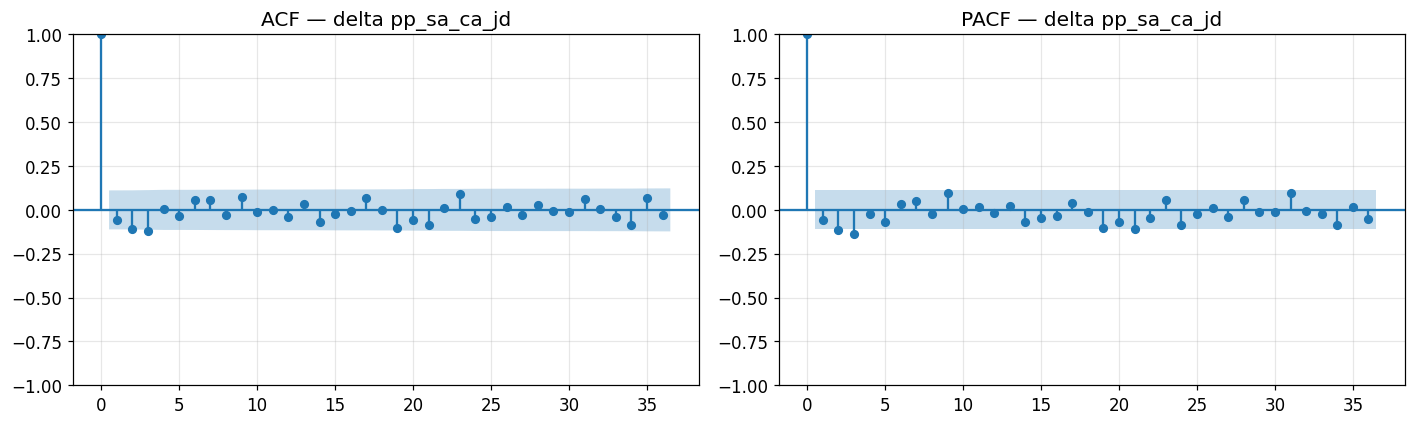

In [10]:
# identifikacia poctu lagov
# ACF => MA (q)
# PACF => AR (p)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(df[TARGET_VAR], lags=36, ax=axes[0], title="ACF — delta pp_sa_ca_jd")
plot_pacf(df[TARGET_VAR], lags=36, ax=axes[1], title="PACF — delta pp_sa_ca_jd")
plt.tight_layout()
plt.show()


In [11]:
# urcenie rozsah testovacej mnoziny a rozdelenie dat na train/test
#X = df[selected_cols]
#y = df[TARGET_VAR]

X = df.drop(columns = [TARGET_VAR])
y = df[TARGET_VAR] 

X_train, X_test = X.iloc[:-TEST_SIZE], X.iloc[-TEST_SIZE:]
y_train, y_test = y.iloc[:-TEST_SIZE], y.iloc[-TEST_SIZE:]

print(f"Trenovacia mnozina: {y_train.index.min().date()} az {y_train.index.max().date()} ({len(y_train)} obs.)")
print(f"Testovacia mnozina: {y_test.index.min().date()} az {y_test.index.max().date()} ({len(y_test)} obs.)")


Trenovacia mnozina: 2000-02-01 az 2023-12-01 (287 obs.)
Testovacia mnozina: 2024-01-01 az 2025-12-01 (24 obs.)


In [27]:
df_train = pd.concat([y_train, X_train], axis= 1)
selected_cols = forward_selection(df_train, target_col=y_train.name, infc="bic")
X_train = X_train[selected_cols]
X_test = X_test[selected_cols]

Forward selection (bic):
--------------------------------------------------
  + 'trzby_priemysel_sa'  bic = 1405.69
  + 'crisis_dummy'  bic = 1343.49
  + 'export_celkovy_sa'  bic = 1311.43
  Zastavenie — pridanie ďalšej premennej nezlepšuje bic.
--------------------------------------------------
Vybrané premenné: ['trzby_priemysel_sa', 'crisis_dummy', 'export_celkovy_sa']
Finálny bic     : 1311.43


In [28]:
# korelacna matica vybranych premennych
df[selected_cols + [TARGET_VAR]].corr()

,trzby_priemysel_sa,crisis_dummy,export_celkovy_sa,pp_sa_ca_jd
trzby_priemysel_sa,1.000000,0.064610,0.737235,0.632102
crisis_dummy,0.064610,1.000000,0.079359,-0.290359
export_celkovy_sa,0.737235,0.079359,1.000000,0.605090
pp_sa_ca_jd,0.632102,-0.290359,0.605090,1.000000


In [29]:
arimax_model = auto_arima(
    y=y_train,
    X=X_train,

    d=0,
    stationary=True,

    seasonal=False,
    m=1,

    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,

    information_criterion="bic",
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

Performing stepwise search to minimize bic
 ARIMA(0,0,0)(0,0,0)[0] intercept   : BIC=1331.207, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : BIC=1318.701, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : BIC=1319.726, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : BIC=1325.823, Time=0.13 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : BIC=1324.329, Time=0.09 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : BIC=1324.012, Time=0.39 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : BIC=1329.696, Time=0.26 sec
 ARIMA(1,0,0)(0,0,0)[0]             : BIC=1313.448, Time=0.09 sec
 ARIMA(2,0,0)(0,0,0)[0]             : BIC=1319.085, Time=0.15 sec
 ARIMA(1,0,1)(0,0,0)[0]             : BIC=1319.073, Time=0.16 sec
 ARIMA(0,0,1)(0,0,0)[0]             : BIC=1314.445, Time=0.22 sec
 ARIMA(2,0,1)(0,0,0)[0]             : BIC=1324.471, Time=0.28 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 1.989 seconds


In [30]:
# odhad modelu
BASE_ORDER = arimax_model.order
SEAS_ORDER = arimax_model.seasonal_order

model_fit = SARIMAX(
    y_train,
    exog              = X_train,
    order             = BASE_ORDER,
    seasonal_order    = SEAS_ORDER,
    enforce_stationarity  = False,
    enforce_invertibility = False,
).fit(disp=False, cov_type="robust")

print(model_fit.summary()) 


                               SARIMAX Results                                
Dep. Variable:            pp_sa_ca_jd   No. Observations:                  287
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -640.526
Date:                Thu, 01 Oct 2026   AIC                           1291.052
Time:                        22:06:51   BIC                           1309.332
Sample:                    02-01-2000   HQIC                          1298.379
                         - 12-01-2023                                         
Covariance Type:               robust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
trzby_priemysel_sa     0.0043      0.001      4.374      0.000       0.002       0.006
crisis_dummy         -21.4618      0.916    -23.422      0.000     -23.258     -19.666
export_celkovy_sa   

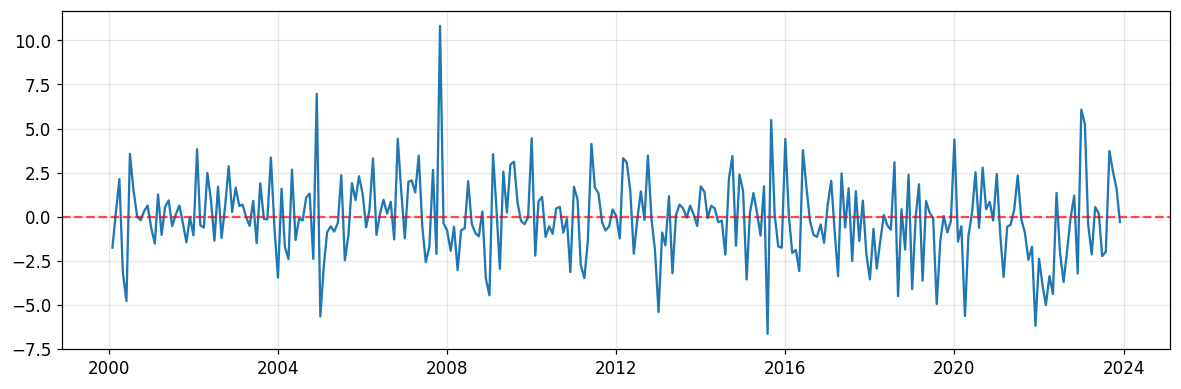

In [35]:
# vizualizacia rezidualov modelu
plt.plot(model_fit.resid)
plt.axhline(y = 0, color = "red", linestyle = "--", alpha = 0.7)

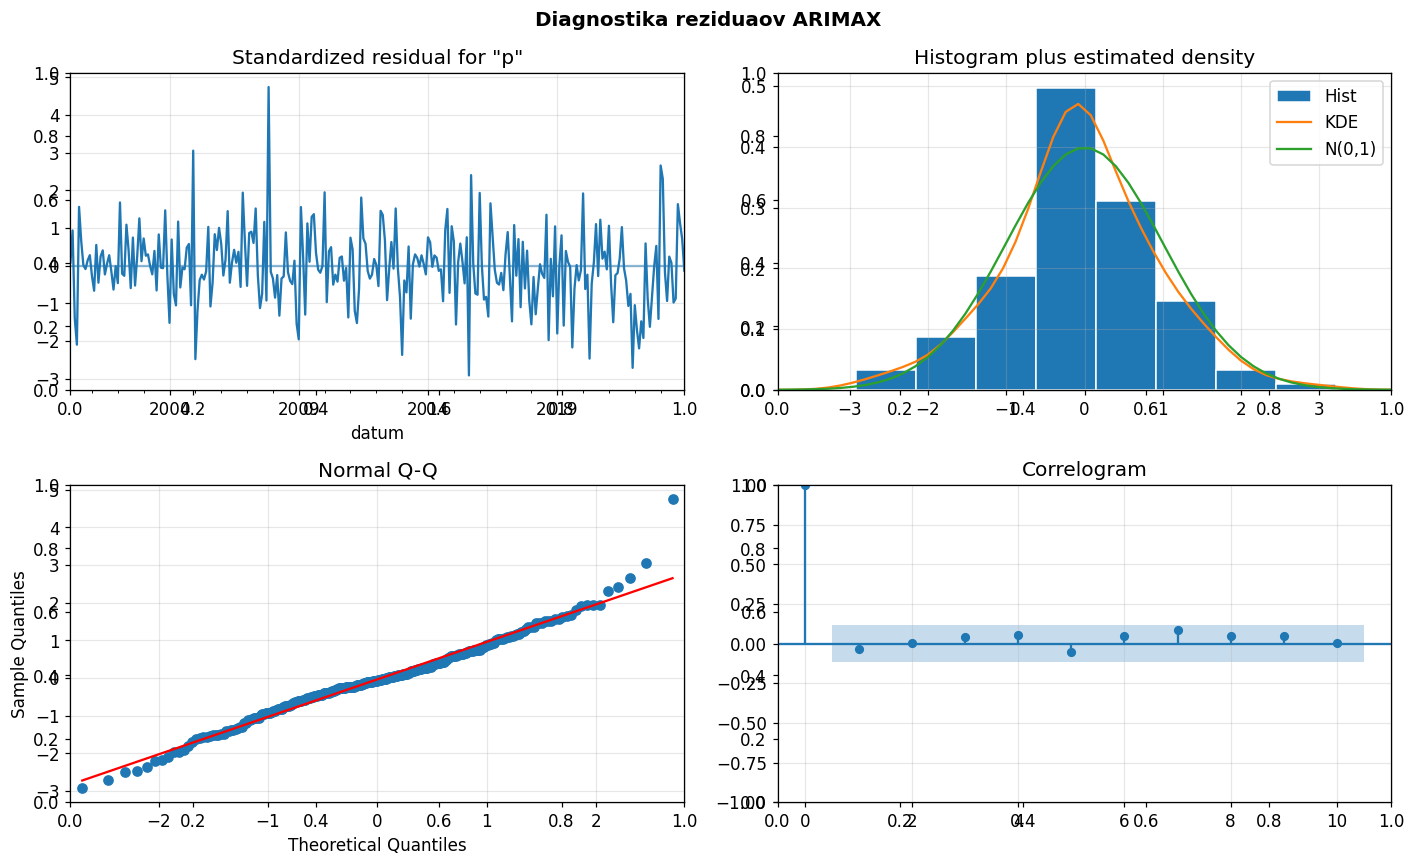

In [36]:
# diagnostika rezidualov
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
model_fit.plot_diagnostics(fig=fig)
plt.suptitle("Diagnostika reziduaov ARIMAX", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [37]:
X_arimax_lag1 = X[selected_cols].shift(1)
df_arimax_eval = (
    pd.concat(
        [y.rename(TARGET_VAR), X_arimax_lag1],
        axis=1,
    )
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

y_diff_arimax = df_arimax_eval[TARGET_VAR]
X_arimax = df_arimax_eval.drop(columns=[TARGET_VAR])

# Povodna nediferencovana uroven pre one-step rekonstrukciu
level_series_arimax = df_pp[TARGET_VAR].loc[y_diff_arimax.index]

# Zaciatok testu musi byt identicky pre ARIMAX, XGBoost aj Elastic Net
test_start_date = y.index[len(y) - TEST_SIZE]

available_test_dates = y_diff_arimax.index[
    y_diff_arimax.index >= test_start_date
]

if available_test_dates.empty:
    raise ValueError(
        "Po lagovani a odstraneni NaN nema ARIMAX ziadne pozorovania "
        "v povodnom testovacom obdobi."
    )

first_test_date_arimax = available_test_dates[0]
initial_train_size_arimax = y_diff_arimax.index.get_loc(
    first_test_date_arimax
)

ar_res = rolling_forecast_arimax(
    X=X_arimax,
    y_diff=y_diff_arimax,
    level_series=level_series_arimax,
    initial_train_size=initial_train_size_arimax,
    order=BASE_ORDER,
    seasonal=False,
    seasonal_order=None,
    refit_every=1,
)

RMSE (diferencia):      2.5590
RMSE (level, onestep):  2.5590
WMAPE (level):          2.12%
ME (level):             -0.6948
Refity:                 24 / 24


In [65]:
results_arimax = ar_res["results"]
results_arimax.to_parquet("data/arimax_res")

diagnostics = ar_res["diagnostics"]
metrics = diagnostics["residual_diagnostics"]

step_diag = ar_res["step_diagnostics"]
step_diag_df = pd.DataFrame(step_diag)
step_diag_df = step_diag_df.set_index("forecast_date")

summary_arimax = ar_res["summary"]
summary_arimax = pd.DataFrame([summary_arimax])
summary_arimax.to_parquet("data/arimax_sum")

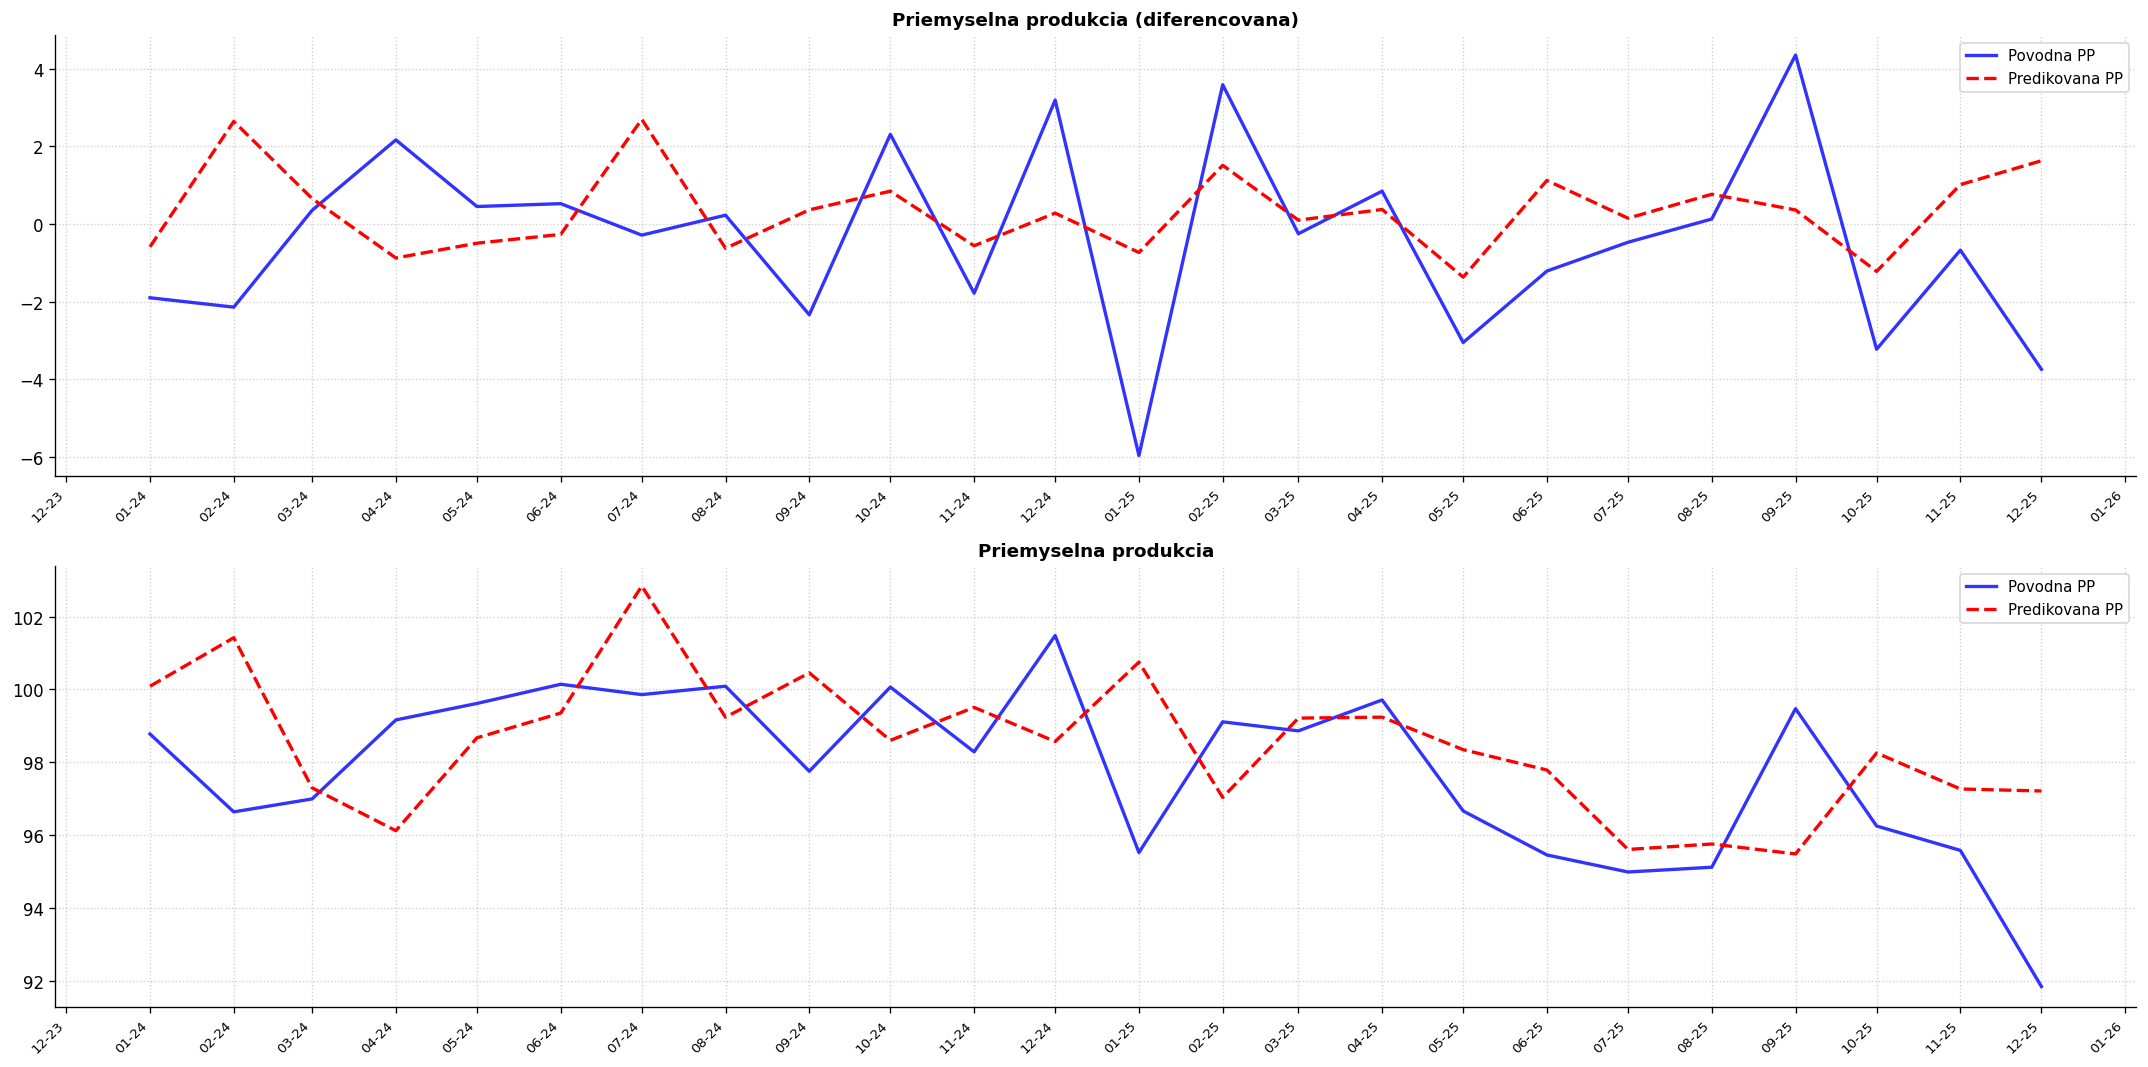

In [39]:
Y_axis = [results_arimax["actual_diff"], results_arimax["predicted_diff"], results_arimax["actual_level"], results_arimax["predicted_level"]]
X_axis = [results_arimax.index] * len(Y_axis)
labels = ["Povodna PP", "Predikovana PP"] * len(Y_axis)
titles = ["Priemyselna produkcia (diferencovana)", "Priemyselna produkcia"]
colors = ["#0000FF", "#FF0000"] * len(Y_axis)
linestyles = ["-","--"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [0.8,1] * len(Y_axis)
fig_size = [18,9]
num_rows = 2
num_cols = 1

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols)

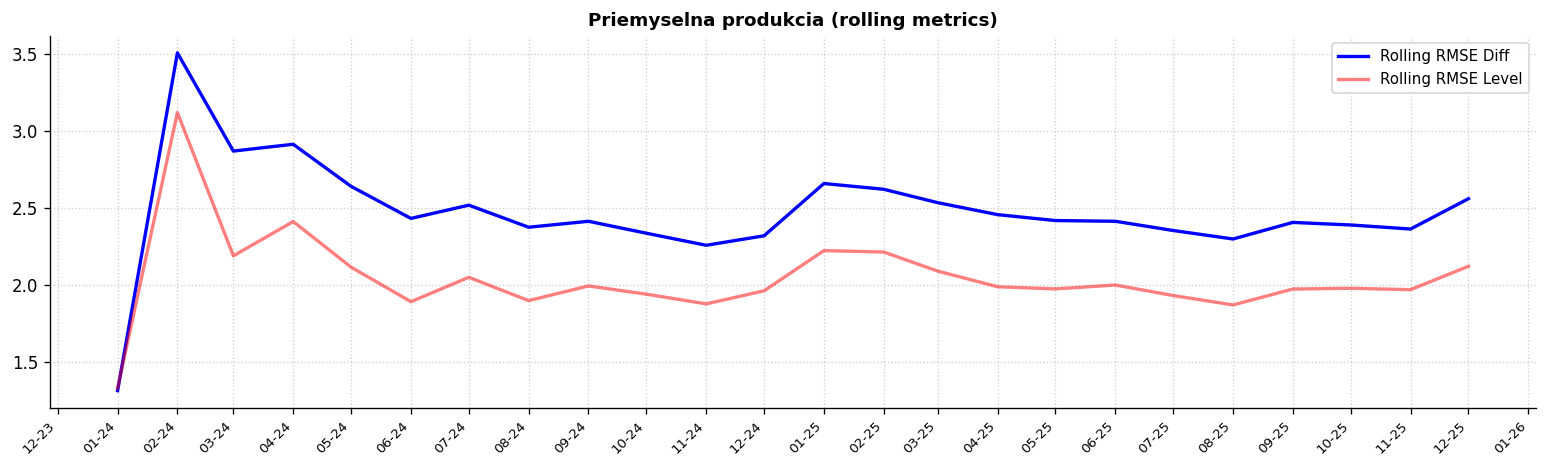

In [19]:
Y_axis = [results_arimax["rolling_rmse_level"], results_arimax["rolling_mape_level"]]
X_axis = [results_arimax.index] * len(Y_axis)
labels = ["Rolling RMSE Diff", "Rolling RMSE Level", "Rolling MAPE Level"] * len(Y_axis)
titles = ["Priemyselna produkcia (rolling metrics)"]
colors = ["#0000FF", "#FF0000", "#008000"] * len(Y_axis)
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [1, 0.5, 1] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1
curves_per_plot = 3

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, curves_per_plot)

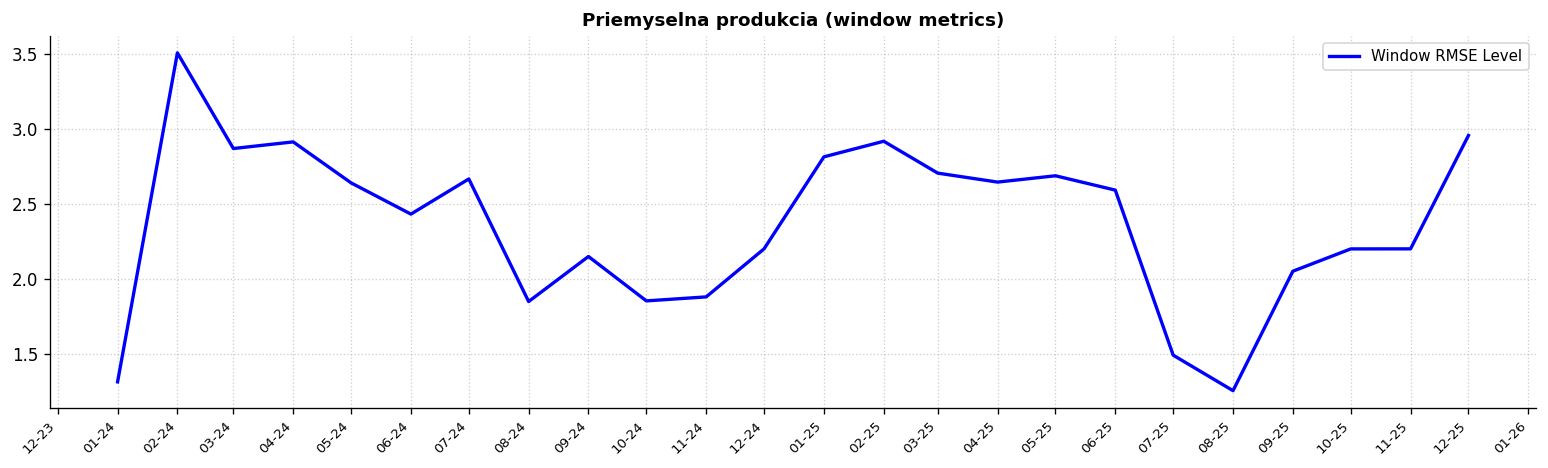

In [20]:
Y_axis = [results_arimax["window6_rmse_level"]] #results_arimax["window6_mape_level"], results_arimax["window6_me_level"]
X_axis = [results_arimax.index] * len(Y_axis)
labels = ["Window RMSE Level"] * len(Y_axis) #, "Window MAPE Level", "Window ME Level"
titles = ["Priemyselna produkcia (window metrics)"]
colors = ["#0000FF"] * len(Y_axis) #, "#FF0000", "#008000"
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [1] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1
curves_per_plot = 3

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, curves_per_plot)

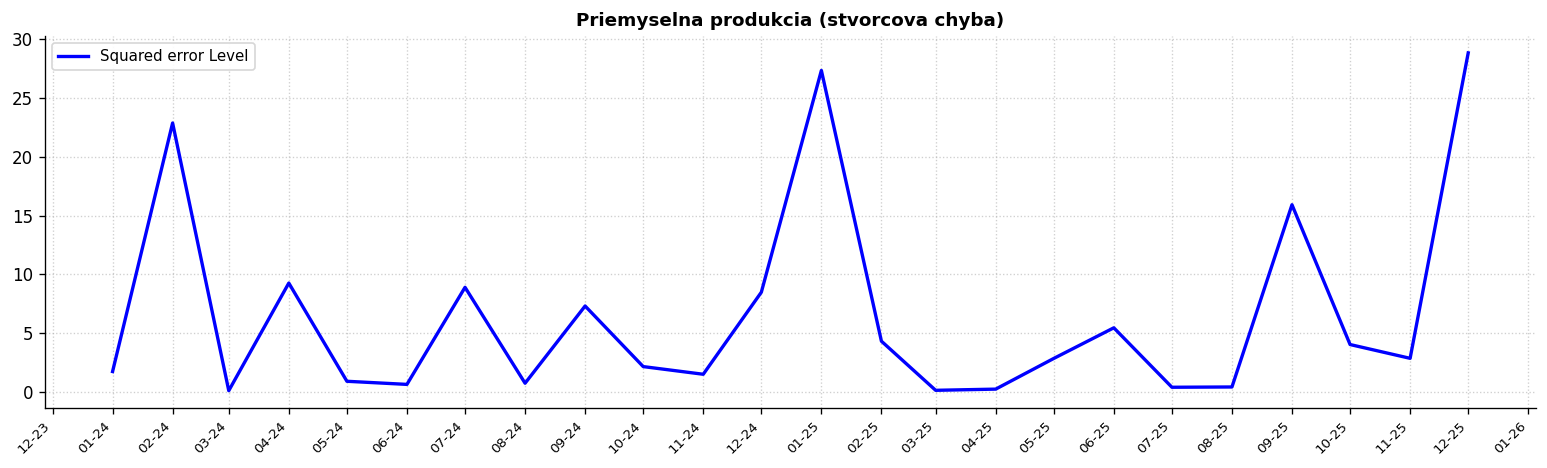

In [21]:
Y_axis = [results_arimax["sq_error_level"]]
X_axis = [results_arimax.index] * len(Y_axis)
labels = ["Squared error Level"] * len(Y_axis)
titles = ["Priemyselna produkcia (stvorcova chyba)"]
colors = ["#0000FF"] * len(Y_axis)
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [1] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1
curves_per_plot = 3

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, curves_per_plot)

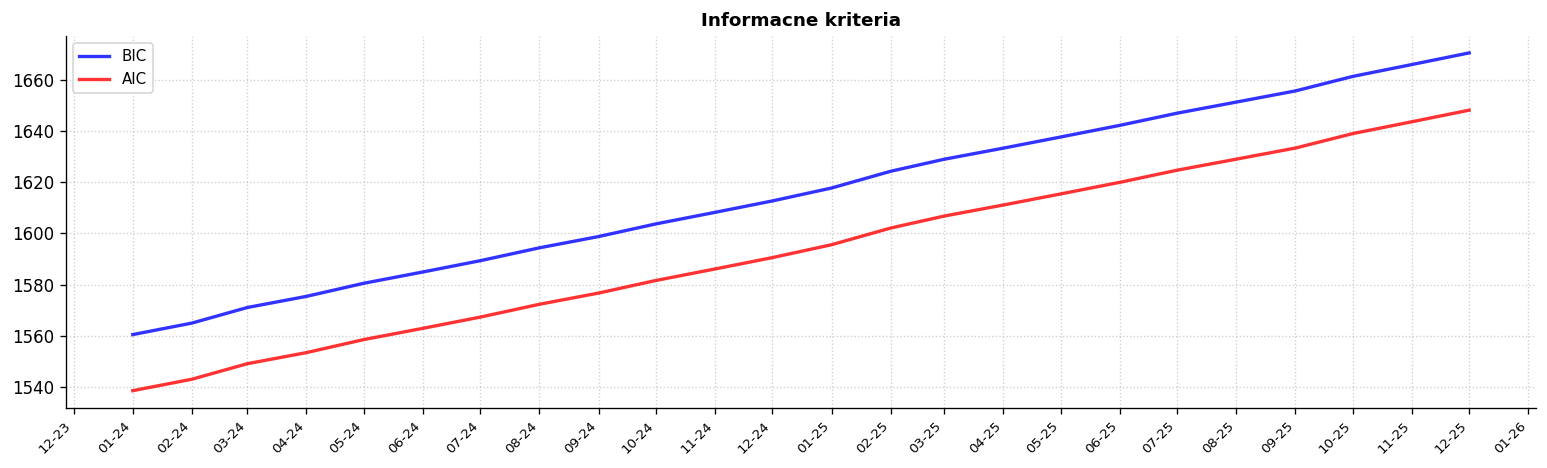

In [69]:
Y_axis = [metrics["bic"], metrics["aic"]]
X_axis = [metrics.index] * len(Y_axis)
labels = ["BIC", "AIC"] * len(Y_axis)
titles = ["Informacne kriteria"]
colors = ["#0000FF", "#FF0000"] * len(Y_axis)
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [0.8] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols)

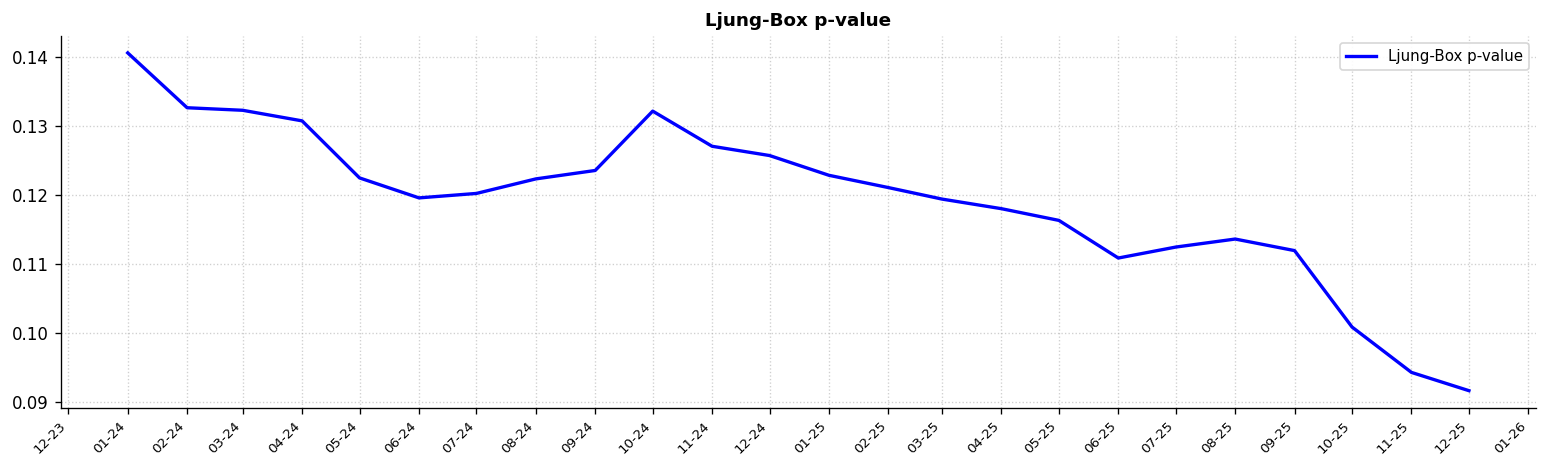

In [73]:
Y_axis = [metrics["ljung_box_pvalue"]]
X_axis = [metrics.index] * len(Y_axis)
labels = ["Ljung-Box p-value"] * len(Y_axis)
titles = ["Ljung-Box p-value"]
colors = ["#0000FF"] * len(Y_axis)
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [1] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols)

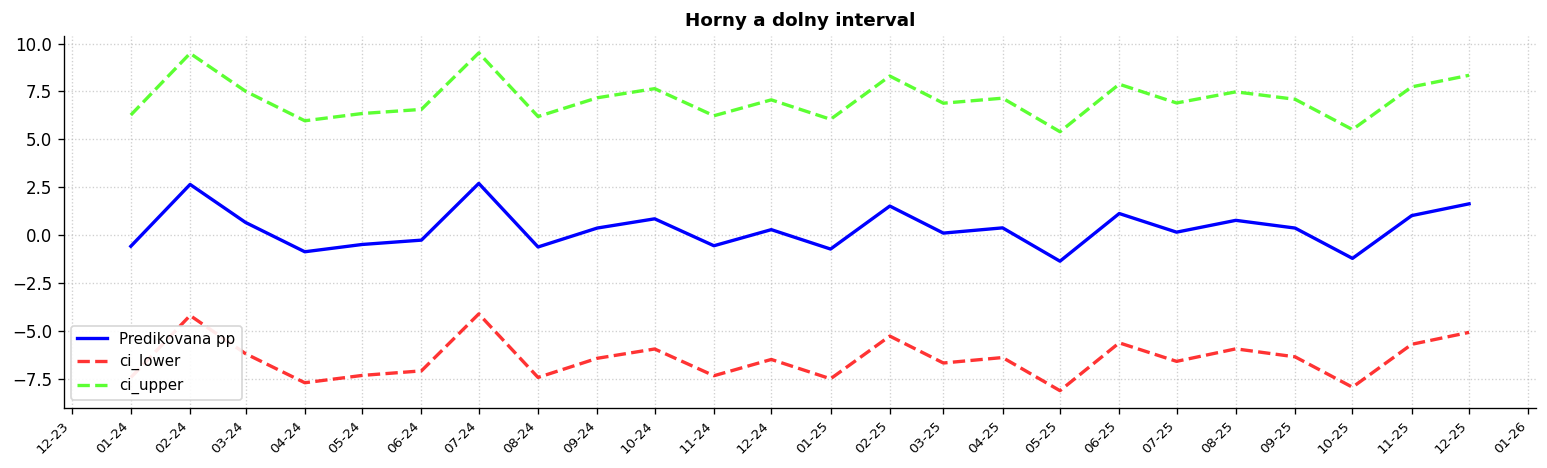

In [75]:
Y_axis = [results_arimax["predicted_diff"], step_diag_df["ci_lower"], step_diag_df["ci_upper"]]
X_axis = [results_arimax.index] * len(Y_axis)
labels = ["Predikovana pp","ci_lower", "ci_upper"] * len(Y_axis)
titles = ["Horny a dolny interval"]
colors = ["#0000FF", "#FF0000", "#33FF00"] * len(Y_axis)
linestyles = ["-", "--", "--"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [1, 0.8, 0.8] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, 3)